# w13-1. AutoML (FLAML) — 모델 선택 + hyperparameter 한 번에

**오늘 할 일**
1. 우리가 지난 몇 주간 한 일을 다시 정리 (모델 6개 × hyperparameter × k)
2. **FLAML** 한 번 호출로 같은 일을 자동으로 (worked example)
3. ✏️ 다른 time_budget / 다른 k로 한 번 더 (quiz)

**데이터**: `skin_irritation_2Ddesc.csv` (지난 시간과 동일)

## 🚨 한 줄 요약
우리가 W9~W12 동안 짠 코드 = **for문 여러 겹 + 모델 6개 grid search + Optuna**.
FLAML은 이걸 **`automl.fit(X, y, task='classification', time_budget=30)` 한 줄**로 함.

## 설치

Colab/Jupyter에서 **한 번만** 실행하면 됨.

> ⚠️ `[automl]`을 빼먹지 마. 안 그러면 핵심 모듈이 같이 안 깔림.

In [2]:
!pip install "flaml[automl]" --quiet

---
# Part A. 데이터 준비

지난 시간과 동일. SelectKBest로 10개 descriptor 선택.

In [3]:
import pandas as pd
import warnings
from sklearn.feature_selection import SelectKBest, f_classif

warnings.filterwarnings('ignore')

df = pd.read_csv('skin_irritation_2Ddesc.csv')
y = df['label']
X = df.drop(columns=['Chemical_Name', 'standardized_smi', 'label'])

# NaN 제거 + 저분산 제거
X = X.dropna(axis=1)
X = X.loc[:, X.std() >= 0.01]

# 상위 10개 descriptor 선택
selector = SelectKBest(f_classif, k=10)
selector.fit(X, y)
cols = X.columns[selector.get_support()]
X_sel = X[cols]

print('X_sel shape:', X_sel.shape)

X_sel shape: (39, 10)


---
# Part B. FLAML 개념

## 🤔 우리가 한 일을 다시 보자

W9 ~ W12에서 이런 패턴을 여러 번 짰어:

```python
for k in k_candidates:
    for model_type in ['LogReg', 'MLP', 'SVM', 'DT', 'RF', 'XGB']:
        for param1 in [...]:
            for param2 in [...]:
                ...
                CV5 점수 계산
                best 후보면 저장
```

→ **for문 여러 겹**. 새 모델 하나 추가하면 for문 한 겹 더.

## 🚀 AutoML이 하는 일

```mermaid
graph LR
    X["📊 X, y"] --> A["🤖 AutoML"]
    A --> M1["LogReg 시도"]
    A --> M2["MLP 시도"]
    A --> M3["RF 시도"]
    A --> M4["XGB 시도"]
    A --> M5["LightGBM 시도"]
    A --> M6["..."]
    M1 --> B["🏆 최고 모델 +<br/>최적 hyperparameter"]
    M2 --> B
    M3 --> B
    M4 --> B
    M5 --> B
    M6 --> B
```

**FLAML**은 Microsoft에서 만든 AutoML 라이브러리.
- 시간 예산(`time_budget`)을 정해 주면 그 안에서 여러 모델과 hyperparameter를 자동으로 탐색
- 내부적으로 똑똑한 search 알고리즘 사용
- 결과: 최고 모델 + 최적 hyperparameter + 점수

## ⚖️ Optuna vs AutoML

| 항목 | Optuna (W12) | FLAML (이번 시간) |
|---|---|---|
| 누가 모델 선택? | **사람** (XGBoost로 고정) | **자동** (LogReg/RF/XGB/... 다 시도) |
| hyperparameter? | 사람이 범위 지정 | 모델별로 미리 잘 정의됨 |
| 시간 조절 | `n_trials` (시도 횟수) | `time_budget` (초 단위) |
| 코드 길이 | 5~7줄 | **3줄** |
| 자유도 | 높음 | 낮음 (편하지만 세밀 조정 어려움) |

---
# Part C. FLAML worked example

## C-1. AutoML 객체 생성 + 학습

**3단계**:
1. `from flaml import AutoML`
2. `automl = AutoML()`
3. `automl.fit(X, y, task='classification', time_budget=30, ...)`

> 💡 `time_budget=30` — 30초 동안 탐색. 데이터가 작으니 짧아도 충분.
> 처음 한 번은 `print` 메시지가 좀 많이 나올 수 있어. 정상.

In [4]:
from flaml import AutoML

automl = AutoML()
automl.fit(X_sel, y, task='classification', time_budget=30, eval_method='cv', verbose=0)

print('완료!')

완료!


## C-2. 결과 확인

학습이 끝나면 `automl` 안에 결과가 들어 있어.
- `best_estimator`: 어떤 모델이 가장 좋았는지 (이름)
- `best_config`: 그 모델의 최적 hyperparameter (dict)
- `best_loss`: 최고 점수 — 단, FLAML은 내부적으로 **loss = 1 - accuracy**로 저장. 정확도로 보려면 `1 - best_loss`.
- `model`: 학습된 모델 객체 자체

In [5]:
print('🏆 최고 모델       :', automl.best_estimator)
print('🔧 최적 hyperparameter:')
for k, v in automl.best_config.items():
    print(f'   {k}: {v}')
print()
print('CV5 정확도         :', round(1 - automl.best_loss, 3))

🏆 최고 모델       : catboost
🔧 최적 hyperparameter:
   early_stopping_rounds: 10
   learning_rate: 0.09999999999999996
   n_estimators: 8192

CV5 정확도         : 1.0


## C-3. 최고 모델로 예측하기

`automl.predict(X)` / `automl.predict_proba(X)` — sklearn처럼 그대로 쓰면 됨.

FLAML은 학습 끝나면 알아서 best 모델로 `predict` 함.

In [6]:
# 학습 데이터에 예측 (sanity check)
y_pred = automl.predict(X_sel)
y_prob = automl.predict_proba(X_sel)

print('train 정확도:', round((y_pred == y).mean(), 3))
print()
print('샘플 3개 예측 결과:')
print('실제 :', list(y[:3]))
print('예측 :', list(y_pred[:3]))
print('확률 :')
print(y_prob[:3].round(3))

train 정확도: 0.974

샘플 3개 예측 결과:
실제 : [1, 0, 0]
예측 : [np.int64(1), np.int64(0), np.int64(0)]
확률 :
[[0.019 0.981]
 [0.963 0.037]
 [0.974 0.026]]


## C-4. 시도한 모델들 살펴보기

`automl.estimator_list` — 시도한 모델 목록.
`automl.best_loss_per_estimator` — 모델별로 찾은 최고 loss.

→ FLAML이 내부에서 "어떤 모델이 강했는지" 한눈에 볼 수 있음.

In [7]:
# 시도한 모델 종류
print('시도한 모델 종류:', automl.estimator_list)
print()

# 모델별 최고 점수 (loss → accuracy로 변환)
for est in automl.estimator_list:
    loss = automl.best_loss_per_estimator.get(est, None)
    if loss is not None and loss < 1e9:
        print(f'{est:15s} → CV 정확도 {round(1 - loss, 3)}')

시도한 모델 종류: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'catboost', 'lrl1']

lgbm            → CV 정확도 0.975
rf              → CV 정확도 0.911
xgboost         → CV 정확도 0.99
extra_tree      → CV 정확도 0.923
xgb_limitdepth  → CV 정확도 0.717
sgd             → CV 정확도 0.739
catboost        → CV 정확도 1.0


---
# Part D. ✏️ Quiz

## ✏️ Quiz 1 — time_budget을 늘리면 결과가 좋아질까?

`time_budget=60` 또는 `120`으로 다시 학습. 30초일 때와 비교.

**힌트**
- C-1 코드를 그대로 복사
- `time_budget=` 값만 바꾸기 (변수 이름은 `automl_long`)
- `best_estimator`, `1 - best_loss`를 30초 결과와 비교

In [12]:
from flaml import AutoML

# ✏️ Quiz 1: time_budget=60 으로 학습 (변수명 automl_long)
automl_long = AutoML()

automl_long.fit(
    X_sel,
    y,
    task='classification',
    time_budget=60,
    eval_method='cv',
    verbose=0
)

# ✏️ best_estimator, CV5 정확도 출력
print('🏆 최고 모델       :', automl_long.best_estimator)

print('🔧 최적 hyperparameter:')
for k, v in automl_long.best_config.items():
    print(f'   {k}: {v}')

print()
print('CV5 정확도         :', round(1 - automl_long.best_loss, 3))

# ✏️ 30초 결과와 비교: 더 좋은 모델/점수가 나왔는지?
print('\n[30초 결과]')
print('모델 :', automl.best_estimator)
print('정확도 :', round(1 - automl.best_loss, 3))

print('\n[60초 결과]')
print('모델 :', automl_long.best_estimator)
print('정확도 :', round(1 - automl_long.best_loss, 3))

🏆 최고 모델       : catboost
🔧 최적 hyperparameter:
   early_stopping_rounds: 10
   learning_rate: 0.09999999999999996
   n_estimators: 8192

CV5 정확도         : 1.0

[30초 결과]
모델 : catboost
정확도 : 1.0

[60초 결과]
모델 : catboost
정확도 : 1.0


## ✏️ Quiz 2 — feature 개수를 바꿔 보기

`SelectKBest(k=20)`으로 feature를 더 많이 줬을 때 FLAML이 더 좋은 점수를 찾는지?

**힌트**
- Part A 코드에서 `k=10` → `k=20`으로 바꾸고 `X_sel20` 만들기
- 같은 `time_budget=30`으로 `automl_k20.fit(X_sel20, y, ...)` 학습
- 결과 비교

In [14]:
from sklearn.feature_selection import SelectKBest, f_classif
from flaml import AutoML

# ✏️ Quiz 2-1: k=20으로 SelectKBest → X_sel20
selector20 = SelectKBest(f_classif, k=20)

selector20.fit(X, y)

cols20 = X.columns[selector20.get_support()]

X_sel20 = X[cols20]

print('X_sel20 shape:', X_sel20.shape)
print('선택된 feature 개수:', len(cols20))

X_sel20 shape: (39, 20)
선택된 feature 개수: 20


In [15]:
# ✏️ Quiz 2-2: AutoML 학습 (변수명 automl_k20, time_budget=30)
from flaml import AutoML

# ✏️ Quiz 2-2: AutoML 학습
automl_k20 = AutoML()

automl_k20.fit(
    X_sel20,
    y,
    task='classification',
    time_budget=30,
    eval_method='cv',
    verbose=0
)

# 결과 출력
print('🏆 최고 모델       :', automl_k20.best_estimator)

print('🔧 최적 hyperparameter:')
for k, v in automl_k20.best_config.items():
    print(f'   {k}: {v}')

print()
print('CV5 정확도         :', round(1 - automl_k20.best_loss, 3))

🏆 최고 모델       : catboost
🔧 최적 hyperparameter:
   early_stopping_rounds: 12
   learning_rate: 0.1604199347807429
   n_estimators: 8192

CV5 정확도         : 1.0


In [16]:
# ✏️ Quiz 2-3: k=10 결과와 비교
print('[k=10 결과]')
print('모델 :', automl.best_estimator)
print('정확도 :', round(1 - automl.best_loss, 3))

print('\n[k=20 결과]')
print('모델 :', automl_k20.best_estimator)
print('정확도 :', round(1 - automl_k20.best_loss, 3))

[k=10 결과]
모델 : catboost
정확도 : 1.0

[k=20 결과]
모델 : catboost
정확도 : 1.0


## ✏️ Quiz 3 — FLAML 결과를 W11처럼 저장 + 새 분자 예측

W11에서 배운 패턴 그대로 — **`features` + `model`을 같이 저장** → 불러와서 새 분자에 예측.

## 🚨 왜 features를 같이 저장?

새 분자에서 descriptor를 계산하면 200개가 넘게 나옴.
→ 학습 때 골랐던 **같은 10개**를 같은 순서로 뽑아야 모델에 넣을 수 있음.
→ 그래서 `cols`(=features)를 모델과 함께 저장.

> 💡 FLAML의 `AutoML` 객체는 내부에서 전처리를 알아서 하므로 W11과 달리 **scaler는 따로 저장 안 해도 됨**.
> 트리 기반(xgboost/rf/lgbm)이 뽑히면 scaling 자체가 불필요하고, 선형 계열이 뽑혀도 FLAML이 내부에서 처리.

**저장 패턴**
```python
saved = {'features': list(cols), 'model': automl}   # scaler 없음
joblib.dump(saved, 'model_automl.joblib')
```

**힌트**
- B-4(W11)와 동일하게 RDKit으로 새 분자 3개 descriptor 계산
- 새 분자: Acetaminophen, Aspirin, Caffeine
- `new_X[features]`로 같은 컬럼만 추출 → `model.predict(...)` (scaler.transform 호출 ❌)

In [17]:
import joblib

# ✏️ Quiz 3-1: features + model을 딕셔너리로 묶어서 저장
# saved = {'features': list(cols), 'model': automl}
# joblib.dump(saved, 'model_automl.joblib')
saved = {
    'features': list(cols),
    'model': automl
}

joblib.dump(saved, 'model_automl.joblib')

print('저장 완료!')

저장 완료!


In [18]:
# ✏️ Quiz 3-2: 불러오기 → features, model 꺼내기
# loaded = joblib.load('model_automl.joblib')
# features = loaded['features']
# model    = loaded['model']
loaded = joblib.load('model_automl.joblib')

features = loaded['features']
model = loaded['model']

print('불러오기 완료!')
print('feature 개수:', len(features))

불러오기 완료!
feature 개수: 10


In [19]:
# ✏️ Quiz 3-3: 학습 데이터로 재현 확인 (원본 정확도와 같으면 OK)
# X_check = X[features]
# y_pred_loaded = model.predict(X_check)
# print('불러온 모델 정확도:', round((y_pred_loaded == y).mean(), 3))
# ✏️ Quiz 3-3: 저장 전과 같은 결과인지 확인
X_check = X[features]

y_pred_loaded = model.predict(X_check)

print('불러온 모델 정확도:',
      round((y_pred_loaded == y).mean(), 3))

불러온 모델 정확도: 0.974


## ✏️ Quiz 3-4 — 새 분자 3개 예측

W11 B-4 패턴 그대로. FLAML 모델은 scaler 없이 바로 예측.

**예측 순서 (2단계)**
1. 학습 때 골랐던 **같은 feature**만 추출 (`features`)
2. 모델로 `predict` / `predict_proba` — ⚠️ scaler.transform 호출 ❌

In [20]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd

# 새로 예측할 분자 3개 (이름 + SMILES)
new_mols = {
    'Acetaminophen': 'CC(=O)Nc1ccc(O)cc1',
    'Aspirin':       'CC(=O)Oc1ccccc1C(=O)O',
    'Caffeine':      'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',
}

# ✏️ (1) 분자별로 RDKit descriptor 계산 → DataFrame으로 정리
# rows = []
# for name, smi in new_mols.items():
#     mol = Chem.MolFromSmiles(smi)
#     desc = Descriptors.CalcMolDescriptors(mol)
#     rows.append(desc)
# desc_names = [n for n, _ in Descriptors._descList]
# new_X = pd.DataFrame(rows, index=new_mols.keys(), columns=desc_names)
rows = []

for name, smi in new_mols.items():

    mol = Chem.MolFromSmiles(smi)

    desc = Descriptors.CalcMolDescriptors(mol)

    rows.append(desc)

# descriptor 이름
desc_names = [n for n, _ in Descriptors._descList]

# DataFrame 생성
new_X = pd.DataFrame(
    rows,
    index=new_mols.keys(),
    columns=desc_names
)

print(new_X.shape)

(3, 217)


In [21]:
# ✏️ (2) 학습 때 골랐던 같은 feature만 추출 (순서 동일)
# new_X_sel = new_X[features]
new_X_sel = new_X[features]

print(new_X_sel.shape)
print(new_X_sel.head())

(3, 10)
               MinAbsEStateIndex     BertzCT       Chi0      Chi1  PEOE_VSA7  \
Acetaminophen           0.115102  253.299498   8.267585  5.181541  24.265468   
Aspirin                 0.016019  343.222868   9.844935  6.109061  12.132734   
Caffeine                0.316574  616.528592  10.455665  6.536581   0.000000   

               SlogP_VSA6  HeavyAtomCount    MolMR  fr_C_O_noCOO  fr_ester  
Acetaminophen   24.265468              11  42.4105             1         0  
Aspirin         24.265468              13  44.7103             1         1  
Caffeine        15.916394              14  51.1960             0         0  


In [22]:
# ✏️ (3) 예측 — FLAML 모델은 scaler.transform 없이 바로 predict
# new_pred = model.predict(new_X_sel)
# new_prob = model.predict_proba(new_X_sel)
new_pred = model.predict(new_X_sel)

new_prob = model.predict_proba(new_X_sel)

In [23]:
# ✏️ (4) 결과 출력 — 분자명, 예측 label, 확률
# print('분자          :', list(new_mols.keys()))
# print('예측 label    :', list(new_pred))
# print('예측 확률(0,1):')
# print(new_prob.round(3))
print('분자          :', list(new_mols.keys()))

print('예측 label    :', list(new_pred))

print('예측 확률(0,1):')
print(new_prob.round(3))

분자          : ['Acetaminophen', 'Aspirin', 'Caffeine']
예측 label    : [np.int64(0), np.int64(0), np.int64(0)]
예측 확률(0,1):
[[0.969 0.031]
 [0.974 0.026]
 [0.723 0.277]]


In [24]:
from flaml import AutoML

automl = AutoML()

automl.fit(X, y,
           task='classification',
           time_budget=30)

[flaml.automl.logger: 05-19 12:34:59] {2375} INFO - task = classification
[flaml.automl.logger: 05-19 12:34:59] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 05-19 12:34:59] {2489} INFO - Minimizing error metric: 1-roc_auc
[flaml.automl.logger: 05-19 12:34:59] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'catboost', 'lrl1']
[flaml.automl.logger: 05-19 12:34:59] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 05-19 12:34:59] {3046} INFO - Estimated sufficient time budget=521s. Estimated necessary time budget=13s.
[flaml.automl.logger: 05-19 12:34:59] {3097} INFO -  at 0.1s,	estimator lgbm's best error=2.5200e-01,	best estimator lgbm's best error=2.5200e-01
[flaml.automl.logger: 05-19 12:34:59] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 05-19 12:34:59] {3097} INFO -  at 0.1s,	estimator lgbm's best error=2.5200e-01,	best estimator lgbm's best error=2.5200e-01
[

In [25]:
automl.best_estimator
automl.best_config
automl.best_loss

0.03199999999999999

In [26]:
1 - automl.best_loss

0.968

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from flaml import AutoML

# 1️⃣ train / test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X_sel,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)

# 2️⃣ AutoML (내부적으로 CV 수행)
automl = AutoML()

automl.fit(
    X_train,
    y_train,
    task='classification',
    time_budget=30,
    eval_method='cv',   # ← 여기서 두 번째 CV
    verbose=0
)

# 3️⃣ test set으로 최종 평가
y_pred = automl.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print('\n🏆 최고 모델 :', automl.best_estimator)

print('CV 점수 :',
      round(1 - automl.best_loss, 3))

print('Test 정확도 :',
      round(acc, 3))

Train shape: (31, 10)
Test shape : (8, 10)

🏆 최고 모델 : xgb_limitdepth
CV 점수 : 1.0
Test 정확도 : 0.875


In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4 1]
 [0 3]]


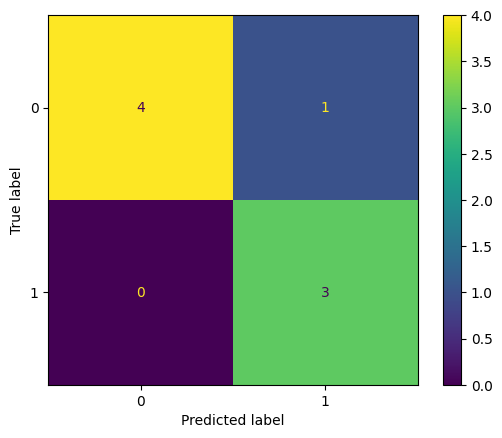

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

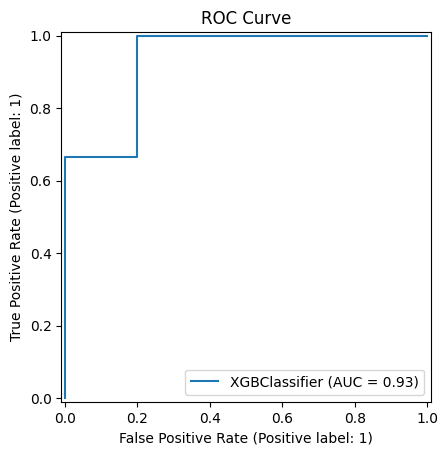

In [33]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# FLAML 내부 실제 모델
model = automl.model.estimator

# ROC curve
RocCurveDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.title('ROC Curve')

plt.show()

In [34]:
from sklearn.metrics import roc_auc_score

# 확률 예측
y_prob = automl.predict_proba(X_test)[:, 1]

# ROC-AUC 계산
auc = roc_auc_score(y_test, y_prob)

print('ROC-AUC:', round(auc, 3))

ROC-AUC: 0.933


---
## 정리 — 우리의 학습 여정

**W9 ~ W13 한 줄 정리**

| 주차 | 내용 | 코드 길이 |
|---|---|---|
| W9 | SelectKBest + LogReg/MLP/SVM grid search | for문 2~3중첩 |
| W10 | DT, RF, XGBoost grid search | for문 3중첩 |
| W11 | 모델 저장/불러오기 (joblib) | 5줄 |
| W12 | **Optuna** — XGBoost 자동 튜닝 | 5~7줄 |
| W13 | **FLAML** — 모델 선택 + 튜닝 자동 | **3줄** |

**언제 무엇을 쓸까?**

```mermaid
graph TD
    Q["어떤 도구를 쓸까?"] --> A1{"모델이 정해져 있나?"}
    A1 -->|Yes| O["✅ Optuna<br/>hyperparameter만 튜닝"]
    A1 -->|No| F["✅ AutoML (FLAML)<br/>모델 선택까지 자동"]
    F --> N{"시간이 매우 부족?"}
    N -->|Yes| Q1["time_budget 작게"]
    N -->|No| Q2["time_budget 넉넉히"]
```

**시험 포인트**
- `from flaml import AutoML` → `AutoML()` → `.fit(..., task='classification', time_budget=...)`
- `best_estimator`, `best_config`, `best_loss` 3개의 의미
- `1 - best_loss` = accuracy
- Optuna vs AutoML 차이 (사람이 모델 고정? AutoML이 자동 선택?)

> ✅ 다음 단계: FLAML로 찾은 최고 모델을 W11에서 배운 `joblib.dump`로 저장하면, 진짜 production-ready 모델!